In [ ]:
import time
import requests
from datetime import datetime, timedelta
from bs4 import BeautifulSoup
from io import StringIO
from tqdm import tqdm
from numpy import nan
import pandas as pd

url = requests.get("https://finance.naver.com/sise/sise_market_sum.naver?sosok=0&page=1")
url.text
# html = BeautifulSoup(url.text, 'html.parser')
html = BeautifulSoup(url.text)
html
table = html.find('table', {'class':'type_2'})
table

table_str = str(table)
table_io = StringIO(table_str)

tables = pd.read_html(table_io)[0]
tables = tables[tables['종목명'].notnull()]

# tables = tables.drop(['N', '토론실'], axis=1)
tables = tables.drop(['N', '토론'], axis=1)
tables.head()

kospi_box = []
for page in tqdm(range(1, 50)):
    url = requests.get(f"https://finance.naver.com/sise/sise_market_sum.naver?sosok=0&page={page}")
    html = BeautifulSoup(url.text)
    
    table = html.find('table', {'class':'type_2'})
    table_str = str(table)
    table_io = StringIO(table_str)

    tables = pd.read_html(table_io)[0]
    tables = tables[tables['종목명'].notnull()]
    
    tables = tables.drop(['N', '토론'], axis=1)
    tables['소속'] = 'KOSPI'
    kospi_box.append(tables)
    time.sleep(1)

kosdaq_box = []
for page in tqdm(range(1, 40)):
    url = requests.get(f"https://finance.naver.com/sise/sise_market_sum.naver?sosok=1&page={page}")
    html = BeautifulSoup(url.text)
    
    table = html.find('table', {'class':'type_2'})
    table_str = str(table)
    table_io = StringIO(table_str)

    tables = pd.read_html(table_io)[0]
    tables = tables[tables['종목명'].notnull()]
    
    tables = tables.drop(['N', '토론'], axis=1)
    tables['소속'] = 'KOSDAQ'
    kosdaq_box.append(tables)
    time.sleep(1)

# stock = pd.concat(kospi_box + kosdaq_box, axis=0)
stock = pd.concat(kospi_box + kosdaq_box, ignore_index=True )
stock

sample = stock.dropna(subset='PER')
sample = sample[(sample['PER'] > 0) & (sample['PER'] < 10)]
sample = sample.sort_values(by='PER')

for i in range(len(sample)):

    data = sample.iloc[i]
    
    name = data['종목명']
    per = data['PER']

    # print(f"{i+1:3d} {name:15s} {per:6.2f}")
    print (f"{name:15s} PER : {per:6.2f}")

sample = stock.dropna(subset='ROE')
sample = sample[sample['ROE']>0]
sample = sample.sort_values("ROE", ascending=False)

for i in range(len(sample)):

    data = sample.iloc[i]
    
    name = data['종목명']
    roe = data['ROE']

    print (f"{name:15s} ROE : {roe:6.2f}")
    print (f"{name:15s} ROE : {roe:6.2f}")




100%|██████████| 39/39 [00:49<00:00,  1.26s/it]

오션인더블유          PER :   0.36
효성화학            PER :   0.41
한창              PER :   0.47
예림당             PER :   0.56
DMS             PER :   0.70
DH오토넥스          PER :   1.16
씨엑스아이           PER :   1.34
SB성보            PER :   1.36
KC코트렐           PER :   1.66
일정실업            PER :   1.76
서전기전            PER :   1.85
웅진              PER :   1.88
포니링크            PER :   1.90
우성              PER :   1.92
서한              PER :   1.95
옵트론텍            PER :   1.96
위메이드플레이         PER :   2.00
전방              PER :   2.03
한진중공업홀딩스        PER :   2.08
베셀              PER :   2.10
케이비아이동국실업       PER :   2.17
일동홀딩스           PER :   2.18
코오롱글로벌          PER :   2.26
유성티엔에스          PER :   2.30
대원산업            PER :   2.30
SG&G            PER :   2.31
에코캡             PER :   2.33
현대해상            PER :   2.33
솔본              PER :   2.36
DSR제강           PER :   2.38
계룡건설            PER :   2.39
넥센타이어1우B        PER :   2.41
현대지에프홀딩스        PER :   2.46
우원개발            PER :   2.48
서연            

In [11]:
from bs4 import BeautifulSoup
from io import StringIO
import requests
import pandas as pd
import time
from tqdm import tqdm

url = requests.get("https://finance.naver.com/sise/dividend_list.naver?&page=1")
html = BeautifulSoup(url.text)

# table = html.find('table', {'class':'type_2'})

table = html.find('table', class_='type_1 tb_ty')
table = StringIO(str(table))
table = pd.read_html(table, header = 1)[0]
table.dropna (subset = '종목명', inplace = True)
table 

total = []
for page in tqdm(range(1, 10)):
    
    url = requests.get(f"https://finance.naver.com/sise/dividend_list.naver?&page={page}")
    html = BeautifulSoup(url.text)

    table = html.find('table', class_='type_1 tb_ty')
    table = StringIO(str(table))
    table = pd.read_html(table, header = 1)[0]
    table.dropna (subset = '종목명', inplace = True)
    total.append(table)
    time.sleep(1)

total_table = pd.concat(total, ignore_index=True)

total_table.sort_values('수익률 (%)', ascending=False, inplace=True)
total_table.sort_values('수익률 (%)', ascending=False).head(10)

total_table = total_table.replace('-', 0)
total_table = total_table.dropna(subset=['배당금', '1년전', '2년전', '3년전'])

total_table['배당금'] = total_table['배당금'].astype(int)
total_table['1년전'] = total_table['1년전'].astype(int)
total_table['2년전'] = total_table['2년전'].astype(int)
total_table['3년전'] = total_table['3년전'].astype(int)

A=total_table['3년전'] < total_table['2년전']
B=total_table['2년전'] < total_table['1년전']
C=total_table['1년전'] < total_table['배당금']

# total_table [A & B & C]
total_table [A & B & C].sort_values('수익률 (%)', ascending=False).head(10)


100%|██████████| 9/9 [00:11<00:00,  1.27s/it]
/var/folders/5r/svt3shzx1tqfcrdcsndx8s2r0000gn/T/ipykernel_5931/549254855.py:32: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  total_table = pd.concat(total, ignore_index=True)


,종목명,현재가,기준월,배당금,수익률 (%),배당성향 (%),ROE (%),PER (배),PBR (배),1년전,2년전,3년전
0,신한글로벌액티브리츠,1290.0,25.08,254,19.69,-76.31,-6.61,-8.52,0.63,126,34,0
3,NH프라임리츠,4380.0,25.05,644,14.70,21.84,9.88,7.79,0.75,540,246,233
18,이지스레지던스리츠,3910.0,25.06,300,7.67,159.24,1.18,43.68,0.49,278,262,261
21,한솔로지스틱스,2795.0,25.12,200,7.16,0,0,0,0,150,100,70
28,HS애드,8360.0,25.03,550,6.58,39.29,11.77,4.63,0.51,450,400,350
30,강원랜드,17890.0,25.04,1170,6.54,51.32,12.08,7.48,0.82,930,350,0
41,KG이니시스,9840.0,25.12,600,6.10,0,0,0,0,500,420,400
49,삼성FN리츠,4855.0,25.10,280,5.77,203.79,0.74,134.57,1.02,272,195,0
58,DB손해보험,128100.0,25.03,6800,5.31,22.05,18.98,3.93,0.66,5300,4600,3500
63,무림페이퍼,1914.0,25.03,100,5.22,10.23,9.39,2.10,0.19,75,50,25


In [13]:
import FinanceDataReader as fdr
df = fdr.StockListing('KOSPI')
# dfs = fdr.DataReader('005930', '2020-01-01')
df  

,Code,ISU_CD,Name,Market,Dept,Close,ChangeCode,Changes,ChagesRatio,Open,High,Low,Volume,Amount,Marcap,Stocks,MarketId
0,005930,KR7005930003,삼성전자,KOSPI,,145500,2,-3800,-2.55,148500,149300,143900,13795375,2009716400600,861307317651000,5919637922,STK
1,000660,KR7000660001,SK하이닉스,KOSPI,,742000,2,-22000,-2.88,764000,764000,737000,1367942,1020401065500,540177754830000,728002365,STK
2,005380,KR7005380001,현대차,KOSPI,,484500,1,4500,0.94,494000,496500,460500,3288873,1565303157250,99205137627000,204757766,STK
3,373220,KR7373220003,LG에너지솔루션,KOSPI,,400750,1,2250,0.56,398000,413500,396500,299740,121202594750,93775500000000,234000000,STK
4,207940,KR7207940008,삼성바이오로직스,KOSPI,,1933000,1,12000,0.62,1922000,1942000,1912000,15643,30168830500,89480408283000,46290951,STK
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
949,001527,KR7001522002,동양2우B,KOSPI,,9090,1,150,1.68,9150,9150,9090,7,63910,2804892210,308569,STK
950,004415,KR7004411005,서울식품우,KOSPI,,1254,1,13,1.05,1254,1254,1237,77,96048,2789523000,2224500,STK
951,002787,KR7002782001,진흥기업2우B,KOSPI,,8250,2,-210,-2.48,8070,8250,8070,771,6344040,2432166000,294808,STK
952,010600,KR7010600005,웰바이오텍,KOSPI,,26,1,12,85.71,15,26,15,16456107,350703929,2364008582,90923407,STK


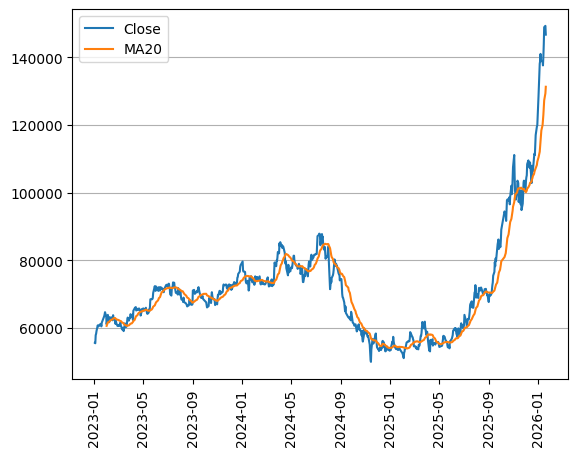

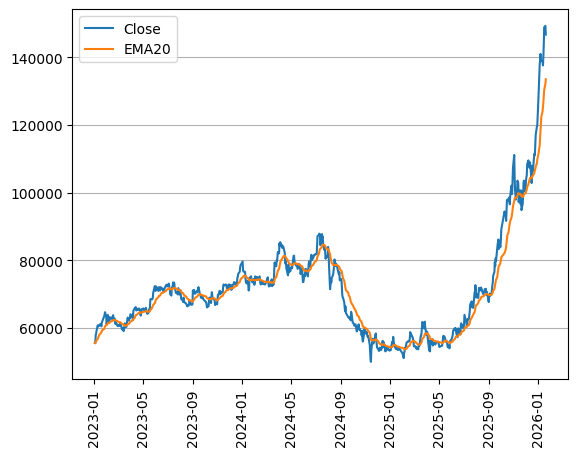

In [17]:
import FinanceDataReader as fdr
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

dfs = fdr.DataReader("005930")
dfs = dfs[dfs.index.year >= 2023]

dfs['MA20'] = dfs['Close'].rolling(window = 20).mean()

plt.plot(dfs['Close'])
plt.plot(dfs['MA20'])
plt.legend(['Close', 'MA20'])
plt.xticks(rotation = 90)
plt.grid(axis = 'y')
plt.show()


dfe = fdr.DataReader("005930")
dfe = dfe[dfe.index.year >= 2023]

# 종가를 기반으로 하는 20일 지수 이동 평균(EMA) 계산
dfe['EMA20'] = dfe['Close'].ewm(span=20, adjust=False).mean()

plt.plot(dfe['Close'])
plt.plot(dfe['EMA20'])
plt.legend(['Close', 'EMA20'])
plt.xticks(rotation = 90)
plt.grid(axis = 'y')
plt.show()

In [ ]:
### EMA를 활용해서 추천 종목 발굴하기

import FinanceDataReader as fdr

stocks = fdr.StockListing('KOSPI') #소스코드에 없어서 임의로 추가함

nameArr = []
for i in range(len(stocks)):

    stock = stocks.iloc[i]
    code = stock['Code']
    name = stock['Name']
    
    df = fdr.DataReader("NAVER:" + code)
    df['EMA20'] = df['Close'].ewm(span=20, adjust=False).mean()
    
    today_data = df.iloc[-1]
    
    if today_data['Close'] < today_data['EMA20']:
        
        nameArr.append(name)
        # print(name)

print (len(nameArr), " 건이 있습니다.")
print (nameArr)

412  건이 있습니다.
['NAVER', '카카오', '기업은행', '삼성에피스홀딩스', '카카오뱅크', 'SK바이오팜', '삼양식품', '유한양행', 'HD현대마린솔루션', '이수페타시스', '삼성카드', '코웨이', 'BNK금융지주', 'JB금융지주', '강원랜드', '영원무역', '동서', 'HD현대인프라코어', '영원무역홀딩스', '농심', 'F&F', '현대해상', '제일기획', 'iM금융지주', '코리안리', 'SK가스', '아모레퍼시픽홀딩스', 'SK아이이테크놀로지', '시프트업', '대웅제약', '녹십자', '동원산업', '달바글로벌', '씨에스윈드', 'SK리츠', 'GS건설', '미래에셋생명', '아시아나항공', 'HDC현대산업개발', '하이트진로', '한일시멘트', 'SK오션플랜트', 'KB발해인프라', 'SK케미칼', '롯데렌탈', '더블유게임즈', '에스디바이오센서', '롯데웰푸드', 'NHN', 'HDC', '쿠쿠홀딩스', '해성디에스', '명인제약', 'GKL', 'GS피앤엘', '케이씨텍', '파미셀', 'TKG휴켐스', '솔루엠', '케이카', '동원시스템즈', '하나투어', '미원상사', '녹십자홀딩스', '프레스티지바이오파마', '신풍제약', '미원에스씨', 'SK이터닉스', '동아쏘시오홀딩스', '금양', 'HD현대에너지솔루션', '카프로', '아세아', '코오롱', '한국쉘석유', 'E1', '제이알글로벌리츠', '비에이치', '바이오노트', '롯데손해보험', 'LF', '신대양제지', '자화전자', '퍼시스', '쿠쿠홈시스', '풀무원', '현대그린푸드', '태영건설', '한일홀딩스', '동아에스티', '삼양사', '신도리코', '아세아시멘트', 'SPC삼립', '애경케미칼', '천일고속', '코람코라이프인프라리츠', '농심홀딩스', '더본코리아', '영진약품', 'KB스타리츠', 'SBS', '대상홀딩스', '대덕', '애경산업', '한섬', '티엠씨', 'KG케미칼', '사조대림', 'SIMPAC', '제이에스코퍼레

In [12]:
### RSI (Relative Strength Index, 상대강도지수)는 기술적 분석에서 널리 사용되는 모멘텀 지표 중 하나입니다. 
### 1978년 웰스 와일더(Welles Wilder)에 의해 개발된 이 지표는 주식이 과매수 또는 과매도 상태인지를 평가하며, 
### 시장의 추세 전환 시점을 예측하는 데 도움을 줍니다.

import FinanceDataReader as fdr
import matplotlib.pyplot as plt
import warnings

def calculate_rsi(data, window=14):
    """
    데이터프레임의 'Close' 열을 사용하여 RSI 값을 계산합니다.
    
    :param data: 주식 데이터가 포함된 데이터프레임
    :param window: RSI를 계산하기 위한 기간 (기본값: 14일)
    :return: RSI가 포함된 데이터프레임
    """
    
    close = data['Close']   # 종가 데이터
    delta = close.diff()    # 종가의 변화량 계산
    
    print ("delta : ",delta)    # 변화량 신경망에서도 기울기/가중치 델타 사용 했었음
    # 상승과 하락을 분리
    gain = delta.where(delta > 0, 0)    # 상승분 양수인 경우 해당값 반환
    loss = -delta.where(delta < 0, 0)   # 하락분 음수인 경우 양수로 변환
    
    # 이동 평균 계산
    avg_gain = gain.rolling(window=window, min_periods=1).mean() # 주어진 기간의 평균 상승분
    avg_loss = loss.rolling(window=window, min_periods=1).mean() # 주어진 기간의 평균 하락분
    
    # RS 및 RSI 계산
    rs = avg_gain / avg_loss        # 상대 강도 (Relative Strength)
    rsi = 100 - (100 / (1 + rs))    # RSI 계산 (Relative Strength Index)
    
    return rsi

# RSI 계산 및 시각화
warnings.filterwarnings("ignore")   # 경고 무시
df=fdr.DataReader("005930")         # 삼성전자 주식 데이터 가져오기
df['RSI']=calculate_rsi(df)         # RSI 계산 및 추가
df = df.dropna()                    # 결측값 제거
df                                  # 데이터 프레임 출력

delta :  Date
2013-11-01       NaN
2013-11-04     -20.0
2013-11-05    -280.0
2013-11-06    -680.0
2013-11-07    -280.0
               ...  
2026-01-15    3600.0
2026-01-16    5000.0
2026-01-19     400.0
2026-01-20   -4100.0
2026-01-21    3600.0
Name: Close, Length: 3000, dtype: float64


,Open,High,Low,Close,Volume,Change,RSI
Date,,,,,,,
2013-11-04,29840,30040,29780,29980,217756,-0.000667,0.000000
2013-11-05,30040,30040,29440,29700,160186,-0.009340,0.000000
2013-11-06,29959,29959,28979,29020,244368,-0.022896,0.000000
2013-11-07,29020,29080,28500,28740,260136,-0.009649,0.000000
2013-11-08,28220,28560,28140,28200,273627,-0.018789,0.000000
...,...,...,...,...,...,...,...
2026-01-15,139000,144000,138300,143900,24701126,0.025659,90.099010
2026-01-16,145300,149500,144300,148900,30000219,0.034746,92.000000
2026-01-19,147200,150600,146600,149300,22762497,0.002686,90.886076


delta :  Date
2013-11-01       NaN
2013-11-04     -20.0
2013-11-05    -280.0
2013-11-06    -680.0
2013-11-07    -280.0
               ...  
2026-01-15    3600.0
2026-01-16    5000.0
2026-01-19     400.0
2026-01-20   -4100.0
2026-01-21    1600.0
Name: Close, Length: 3000, dtype: float64


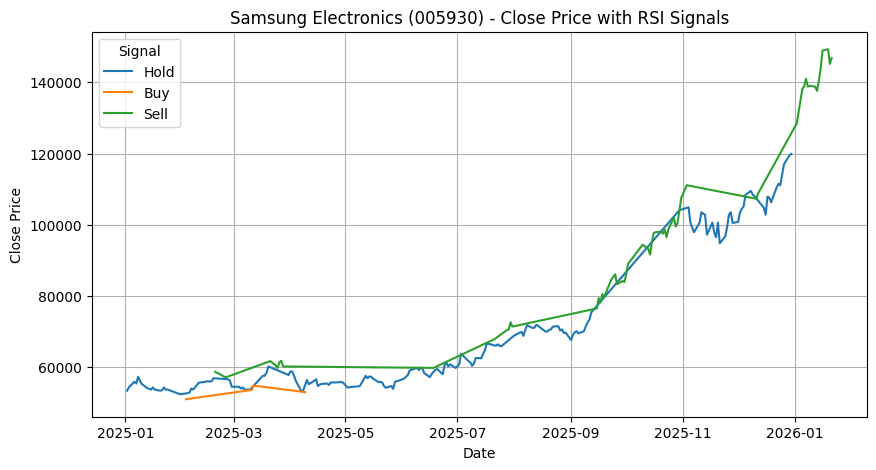

,Code,Name
0,005930,삼성전자
1,000660,SK하이닉스
2,005380,현대차
3,373220,LG에너지솔루션
4,005935,삼성전자우
...,...,...
949,001527,동양2우B
950,004415,서울식품우
951,002787,진흥기업2우B
952,010600,웰바이오텍


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import FinanceDataReader as fdr
import warnings

df = fdr.DataReader("005930")
df['RSI'] = calculate_rsi(df)   # RSI 계산 및 추가 - 위헤서 선언한 calculate_rsi 함수 사용
df = df.dropna()

# 새로운 열 'Signal' 추가하는 함수 정의
def get_signal(rsi):
    if rsi <= 30:
        return 'Buy'
    elif rsi >= 70:
        return 'Sell'
    else:
        return 'Hold'

# 데이터프레임에 새로운 열 추가
# RSI 값에 따라 'Buy', 'Sell', 'Hold' 신호 할당, apply(get_signal) 함수 사용
df['Signal'] = df['RSI'].apply(get_signal)  

plt.figure(figsize = (10, 5))   #그래프 크기 설정

df2 = df[df.index.year >= 2025]

sns.lineplot(data=df2, x = df2.index, y = 'Close', hue = 'Signal') #종가를 기준으로 신호에 따라 선 그래프 그리기
plt.title("Samsung Electronics (005930) - Close Price with RSI Signals")
plt.xlabel("Date")
plt.ylabel("Close Price")

plt.grid()
plt.show()



In [ ]:
stocks = fdr.StockListing('KOSPI') [['Code', 'Name']] 
print(len(stocks))
for i in range (len(stocks)):
    stock = stocks.iloc[i]      # stocks dataframe 의 i번째 행 
    code = stock['Code']
    name = stock['Name']
    df = fdr.DataReader("Naver: " + code)
    df['RSI'] = calculate_rsi(df)
    today_data = df.iloc[-1]['RSI']     # dataframe 의 마지막 행

    if today_data > 70:
        print(f"{name} : 매도 신호 !")
    elif today_data < 30:
        print(f"{name} : 매수 신호 !")

2895
delta :  Date
2013-11-01       NaN
2013-11-04     -20.0
2013-11-05    -280.0
2013-11-06    -680.0
2013-11-07    -280.0
               ...  
2026-01-15    3600.0
2026-01-16    5000.0
2026-01-19     400.0
2026-01-20   -4100.0
2026-01-21    3400.0
Name: Close, Length: 3000, dtype: float64
삼성전자 : 매도 신호 !
delta :  Date
2013-11-01        NaN
2013-11-04     -200.0
2013-11-05     -500.0
2013-11-06      -50.0
2013-11-07     -150.0
               ...   
2026-01-15     7000.0
2026-01-16     7000.0
2026-01-19     8000.0
2026-01-20   -21000.0
2026-01-21    -1500.0
Name: Close, Length: 3000, dtype: float64
SK하이닉스 : 매도 신호 !
delta :  Date
2013-11-01        NaN
2013-11-04    -6000.0
2013-11-05    -3500.0
2013-11-06     5500.0
2013-11-07     4000.0
               ...   
2026-01-15    10500.0
2026-01-16    -9000.0
2026-01-19    67000.0
2026-01-20    -1000.0
2026-01-21    47000.0
Name: Close, Length: 3000, dtype: float64
현대차 : 매도 신호 !
delta :  Date
2022-01-27        NaN
2022-01-28   -55000.0
2022-02-

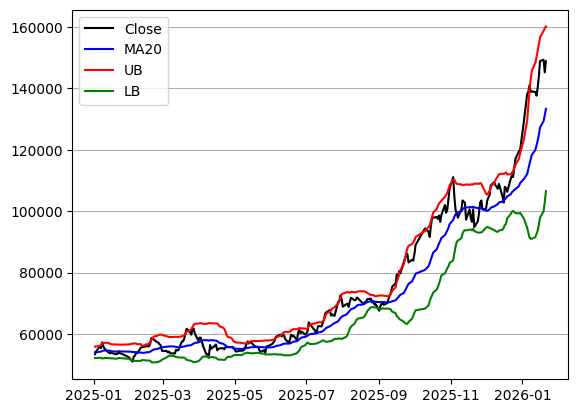

In [26]:
# John Bollinger
# 상대적 과매수 과매도 상태를 식별, 추세의 변화나 가격의 이동을 예측하는 데 유용 

import pandas as pd
import numpy as np
import FinanceDataReader as fdr
import matplotlib.pyplot as plt

name = "삼성전자"
code = "005930"
df = fdr.DataReader(code)

df['MA20'] = df['Close'].rolling(window = 20).mean()    #평균
df['STD20'] = df['Close'].rolling(window = 20).std()    #표준편차

df['UB'] = df['MA20'] + 2 * df['STD20']
df['LB'] = df['MA20'] - 2 * df['STD20']

df = df[df.index.year >= 2025]

plt.plot(df['Close'], color = 'black')
plt.plot(df['MA20'], color = 'blue')
plt.plot(df['UB'], color = 'red')
plt.plot(df['LB'], color = 'green')

plt.grid(axis = 'y')
plt.legend(['Close', 'MA20', 'UB', 'LB'])
# plt.xticks(rotation = 90)   # x축의 눈금 label 을 90도 회전시킨다
plt.show()


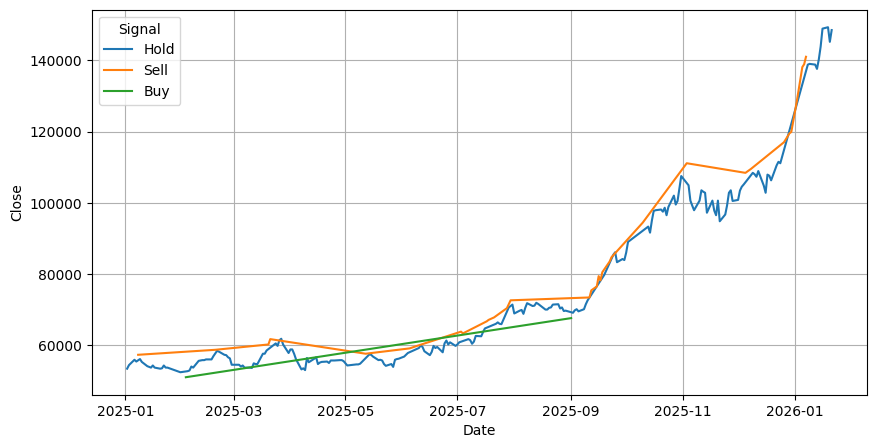

In [ ]:
# 볼린저 밴드 신호 생성 함수 정의
def get_bollinger_signal(row):
    if row['Close'] < row['LB']:
        return 'Buy'
    elif row['Close'] > row['UB']:
        return 'Sell'
    else:
        return 'Hold'

# 주식 데이터 가져오기
name = "삼성전자"
code = "005930"
df = fdr.DataReader(code)

# 볼린저 밴드 계산하여 데이터 프레임에 추가
df['MA20'] = df['Close'].rolling(window = 20).mean() # 20일 이동 평균
df['STD20'] = df['Close'].rolling(window = 20).std() # 20일 표준 편차
df['UB'] = df['MA20'] + 2 * df['STD20']     # 볼린저 상한 밴드 - 일정 표준 편자 보통 2 표준 편차
df['LB'] = df['MA20'] - 2 * df['STD20']     # 볼린저 하한 밴드 - 일정 표준 편자 보통 2 표준 편차
# 종가가 상한 보다 높을때 팔고 하한보다 낮을때 산다

# 2025 이후로 필터링 
df2 = df[df.index.year >= 2025]

# 각 행에 대하여 볼린저 밴드 신호를 계산하여 Signal 열에 추가
df2['Signal'] = df2.apply(get_bollinger_signal, axis=1)

plt.figure(figsize = (10, 5))

sns.lineplot(data=df2, x = df2.index, y = 'Close', hue = 'Signal')

plt.grid()
plt.show()

In [21]:
import FinanceDataReader as fdr

stocks = fdr.StockListing("KOSDAQ")

stocks.dropna()
#stocks.dropna(subset='Code')

sCnt = len(stocks)
aCnt = 30
print (f"{sCnt} 개의 주식중 {aCnt} 개를 검사")
for i in range(aCnt):
#for i in range(10):

    data = stocks.iloc[i]

    code = data['Code']
    name = data['Name']

    df = fdr.DataReader(code)

    df['MA20'] = df['Close'].rolling(window = 20).mean()
    df['STD20'] = df['Close'].rolling(window = 20).std()
    
    df['UB'] = df['MA20'] + 2 * df['STD20']
    df['LB'] = df['MA20'] - 2 * df['STD20']

    today = df.iloc[-1]

    if today['Close'] < today['LB']:
        print(f"{name} @@@ 매수 신호입니다!")
    elif today['Close'] > today['UB']:
        print(f"{name} *** 매도 신호입니다!")

1828 개의 주식중 30 개를 검사
알테오젠 @@@ 매수 신호입니다!
에이비엘바이오 @@@ 매수 신호입니다!
리가켐바이오 @@@ 매수 신호입니다!
현대무벡스 *** 매도 신호입니다!
펩트론 @@@ 매수 신호입니다!
디앤디파마텍 @@@ 매수 신호입니다!
보로노이 @@@ 매수 신호입니다!


HTTPError: 404 Client Error: Not Found for url: https://query2.finance.yahoo.com/v8/finance/chart/0009K0?period1=315500400&period2=1768982124&interval=1d&includeAdjustedClose=true

In [11]:
import numpy as np

# 수익률 데이터 :: 5% 7% -2% 10% 4%
returns = np.array([0.05, 0.07, -0.02, 0.10, 0.04])

# 평균 수익률 계산
mean_return = np.mean(returns)

# 분산 계산 :: 각 수익률에서 평균을 뺀 값을 제곱한 후 평균을 계산
variance = np.mean((returns - mean_return) ** 2)

# 표준편차 계산
std_dev = np.sqrt(variance)
std_dev

0.03969886648255842

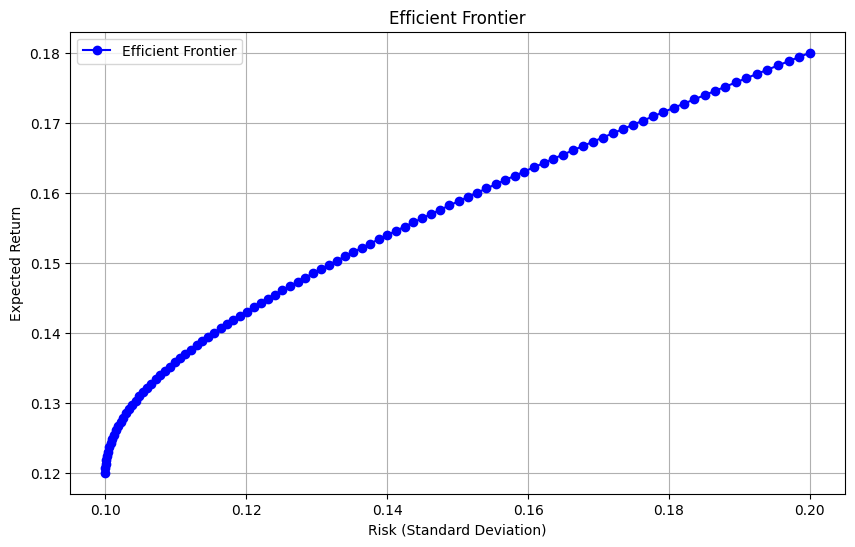

In [10]:
# 효율적 투자선 
# 특정 위험 수준 에서 최대의 이익 
# 특정 이익 수준에서 최소의 위험 있는 최적의 포트폴리오 조합

import numpy as np
import matplotlib.pyplot as plt

# 예시 자산의 수익률과 표준편차 (리스크)
returns = np.array([0.12, 0.18])  # 자산의 기대 수익률 expected return
risks = np.array([0.1, 0.2])      # 자산의 표준편차 (리스크)
correlation = 0.5                 # 두 자산의 상관관계

# 공분산 행렬 계산. *****
cov_matrix = np.array([[risks[0]**2, risks[0]*risks[1]*correlation],
                       [risks[0]*risks[1]*correlation, risks[1]**2]])

# 포트폴리오 수익률과 리스크 계산
def portfolio_performance(weights, returns, cov_matrix):
    portfolio_return = np.sum(weights * returns)
    portfolio_risk = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    return portfolio_return, portfolio_risk

# 다양한 포트폴리오의 수익률과 리스크 계산
weights_list = []
portfolio_returns = []
portfolio_risks = []

for w1 in np.linspace(0, 1, 100):
    w2 = 1 - w1
    weights = np.array([w1, w2])    # 가중치를 넘파이 배열로 정의 *****
    ret, risk = portfolio_performance(weights, returns, cov_matrix)
    weights_list.append(weights)
    portfolio_returns.append(ret)
    portfolio_risks.append(risk)

# 효율적 투자선 그리기
plt.figure(figsize=(10, 6))
plt.plot(portfolio_risks, portfolio_returns, 'b-o', label='Efficient Frontier')
plt.xlabel('Risk (Standard Deviation)')
plt.ylabel('Expected Return')
plt.title('Efficient Frontier')
plt.legend()
plt.grid(True)
plt.show()

In [7]:
# 최고의 투자 비율 찾기

import FinanceDataReader as fdr

stocks = fdr.DataReader(['AAPL', 'TSLA', 'META'])
stocks = stocks.dropna()
stocks

daily_ret = stocks.pct_change()     # 일간 수익율 계산
annual_ret = stocks.mean()          # 평균 수익율 계산

daily_cov = daily_ret.cov()         # 일간 수익율 공분산
annual_cov = daily_cov * 252        # 년간 수익율 공분산

# 초기화 :: 수익율, 리스크, 가중치
port_ret = []
port_risk = []
port_weights = []

In [6]:
stocks = fdr.DataReader(['AAPL', 'TSLA', 'META'])

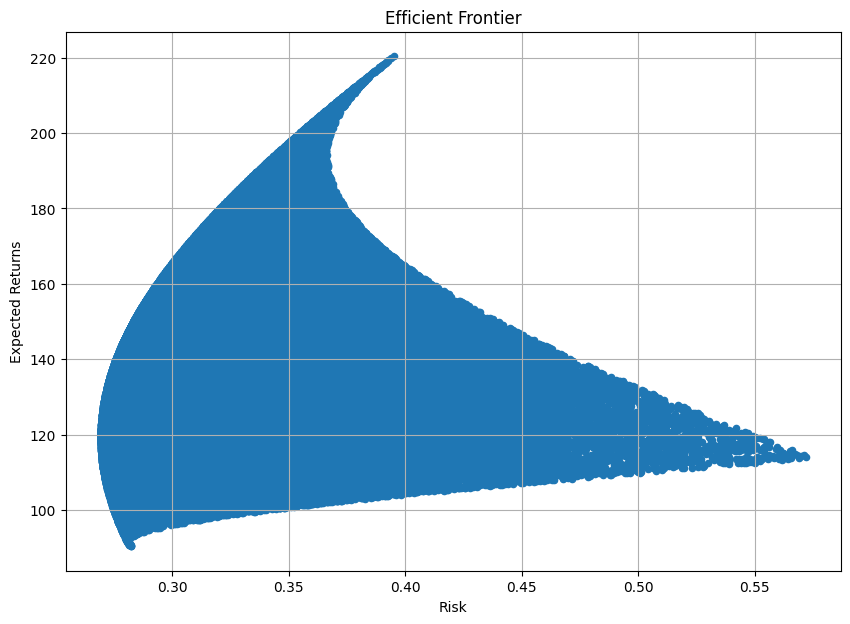

In [8]:
# Monte Carlo Simulation
# 포트폴리오 이론에서 최적의 투자비율을 구하는것에 적용

import pandas as pd
import matplotlib.pyplot as plt

for i in range(100000):

    # 랜덤 가중치 생성 
    weights = np.random.random(3)
    weights /= np.sum(weights)

    # 포트폴리오 수익율 및 리스크 계산
    returns = np.dot(weights, annual_ret)       # 예상 수익율 :: 가중치와 연간수익율의 내적
    risk = np.sqrt(np.dot(weights.T, np.dot(annual_cov, weights)))  # 리스크 (표준편차) :: 가중치 와 연간공분산 행렬

    # 성과 저장
    port_ret.append(returns)
    port_risk.append(risk)
    port_weights.append(weights)

# 포트롤리오 데이터 프레임 생성
portfolio = {'Returns' : port_ret, "Risk" : port_risk}

for i, s in enumerate(stocks.columns):
    portfolio[s] = [weight[i] for weight in port_weights]

# 테이터 프레임 생성 및 정렬
df = pd.DataFrame(portfolio)
df = df[['Returns', 'Risk'] + [s for s in stocks.columns]]
df

# ===============
# 결과 시각화
# ===============

# 산점도 그리기
df.plot.scatter(x = 'Risk', y = 'Returns', figsize = (10, 7), grid = True)

plt.title("Efficient Frontier")
plt.xlabel("Risk")
plt.ylabel("Expected Returns")
plt.show()

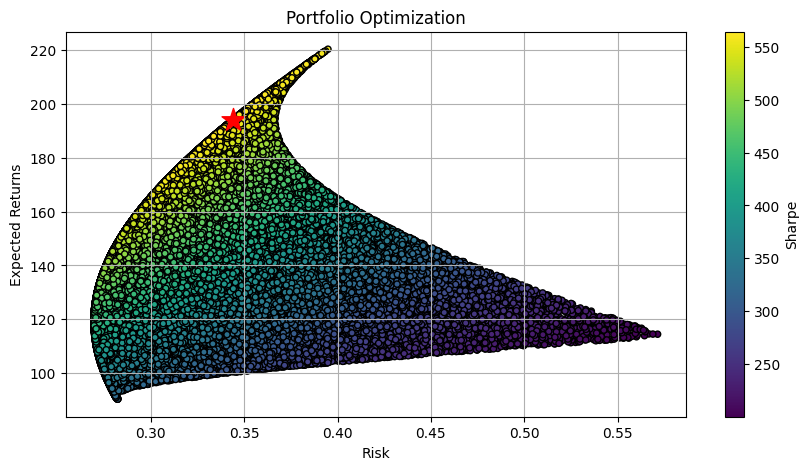

In [9]:
# 샤프 지수 Sharpe Ratio
# 포트폴리오의 상과를 평가하는데 사용 :: 위험대비 수익율을 측정, 포트폴리오의 초과수익율을 단위 리스크당 얼마나 얻었나

daily_ret = stocks.pct_change()
annual_ret = stocks.mean()

daily_cov = daily_ret.cov()
annual_cov = daily_cov * 252

port_ret = []
port_risk = []
port_weights = []
sharpe_ratio = []

for i in range(100000):

    weights = np.random.random(3)
    weights /= np.sum(weights)

    returns = np.dot(weights, annual_ret)
    risk = np.sqrt(np.dot(weights.T, np.dot(annual_cov, weights)))

    port_ret.append(returns)
    port_risk.append(risk)
    port_weights.append(weights)
    sharpe_ratio.append(returns / risk)

portfolio = {'Returns' : port_ret, "Risk" : port_risk, 'Sharpe' : sharpe_ratio}

for i, s in enumerate(stocks.columns):
    portfolio[s] = [weight[i] for weight in port_weights]

df = pd.DataFrame(portfolio)
df = df[['Returns', 'Risk', 'Sharpe'] + [s for s in stocks.columns]]

max_sharpe = df.loc[df['Sharpe'] == df['Sharpe'].max()]
max_sharpe

# 시각화
df.plot.scatter(x = 'Risk', y = 'Returns', c = 'Sharpe', cmap = 'viridis', edgecolors = 'k', figsize = (10, 5), grid = True)
plt.scatter(x = max_sharpe['Risk'], y = max_sharpe['Returns'], c = 'r', marker = '*', s = 300)
plt.title('Portfolio Optimization')
plt.xlabel("Risk")
plt.ylabel("Expected Returns")
plt.show()


In [3]:
### 인공지능 머신러닝 딥러닝 - 신경망
### 머신리닝 - 지도, 비지도, 강화

# 미래 주식 가격 예측하기

import FinanceDataReader as fdr
import numpy as np

df = fdr.DataReader("005930").dropna()

x = []
y = []

for i in range(len(df) - 1):
    
    a = df.iloc[i].to_numpy()
    b = df.iloc[i+1]['Close']
    
    x.append(a)
    y.append(b)

# df 값을 넘파이 배열에 저장    
x = np.array(x) 
y = np.array(y)

print(x)
print(y)


[[ 2.98400000e+04  3.00400000e+04  2.97800000e+04  2.99800000e+04
   2.17756000e+05 -6.66666667e-04]
 [ 3.00400000e+04  3.00400000e+04  2.94400000e+04  2.97000000e+04
   1.60186000e+05 -9.33955971e-03]
 [ 2.99590000e+04  2.99590000e+04  2.89790000e+04  2.90200000e+04
   2.44368000e+05 -2.28956229e-02]
 ...
 [ 1.45300000e+05  1.49500000e+05  1.44300000e+05  1.48900000e+05
   3.00002190e+07  3.47463516e-02]
 [ 1.47200000e+05  1.50600000e+05  1.46600000e+05  1.49300000e+05
   2.27624970e+07  2.68636669e-03]
 [ 1.48500000e+05  1.49300000e+05  1.43900000e+05  1.45200000e+05
   2.40592180e+07 -2.74614869e-02]]
[ 29700.  29020.  28740. ... 149300. 145200. 149500.]


In [1]:
# KNN 새로운/기존 데이터 포인트 간의 거리를 계산 : 분류/회귀
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
import FinanceDataReader as fdr
import pandas as pd

df = fdr.DataReader("005930").dropna()

x = []
y = []

for i in range(len(df) - 1):
    
    a = df.iloc[i].to_numpy()
    b = df.iloc[i+1]['Close']
    
    x.append(a)
    y.append(b)
    
train_x, test_x, train_y, test_y = train_test_split(x, y)

model = KNeighborsRegressor()
model.fit(train_x, train_y)
score = model.score(test_x, test_y)

today_data = df.iloc[-1].to_numpy()

pred = model.predict([today_data])[0]

date = str(df.iloc[-1].name + pd.Timedelta(days=1)).split()[0]
print(f"{date}의 삼성전자의 주식 예측 가격은 {int(pred):,}원입니다. 오차 범위는 {(1 - score) * 100:.2f}% 입니다.")


2026-01-22의 삼성전자의 주식 예측 가격은 63,000원입니다. 오차 범위는 24.21% 입니다.
